<div style="background: linear-gradient(135deg, #1a1a2e, #0f3460); border-radius: 16px; padding: 36px; font-family: 'Segoe UI', sans-serif; border: 1px solid #e94560;">

<h1 style="color:#e94560; margin:0 0 8px 0; font-size:2rem;">🧠 Employee Attrition Prediction</h1>
<h3 style="color:#64ffda; margin:0 0 20px 0; font-weight:400;">Week 2 Project</h3>

<hr style="border-color:#0f3460; margin-bottom:20px;">

<h3 style="color:#e94560;">📌 Problem Statement</h3>
<p style="color:#ccd6f6; line-height:1.8;">
Employee attrition — when employees voluntarily leave a company — costs organizations crores every year in hiring,
training, and lost productivity. This project builds a <b style="color:#64ffda;">Machine Learning classification system</b>
that predicts whether an individual employee is likely to leave, based on factors such as salary, overtime, job satisfaction,
work-life balance, and career growth. The goal is to give HR teams an early-warning tool so they can intervene
<i>before</i> a valuable employee walks out the door.
</p>

<h3 style="color:#e94560;">📦 Dataset</h3>
<p style="color:#ccd6f6; line-height:1.8;">
<b style="color:#64ffda;">IBM HR Analytics Employee Attrition Dataset</b> — sourced from Kaggle.<br>
<b>1,470 employees</b> · <b>35 features</b> · Binary target: <b>Attrition (Yes / No)</b><br>
Features include: Age, Department, JobRole, MonthlyIncome, OverTime, WorkLifeBalance, YearsAtCompany, and more.
</p>

<h3 style="color:#e94560;">🗂️ Project Structure</h3>
<table style="color:#ccd6f6; border-collapse:collapse; width:100%;">
  <tr style="border-bottom:1px solid #0f3460;"><td style="padding:6px 12px; color:#64ffda;"><b>Task 1</b></td><td style="padding:6px 12px;">Data Loading & Exploration</td></tr>
  <tr style="border-bottom:1px solid #0f3460;"><td style="padding:6px 12px; color:#64ffda;"><b>Task 2</b></td><td style="padding:6px 12px;">Data Cleaning & Preprocessing</td></tr>
  <tr style="border-bottom:1px solid #0f3460;"><td style="padding:6px 12px; color:#64ffda;"><b>Task 3</b></td><td style="padding:6px 12px;">Exploratory Data Analysis (EDA)</td></tr>
  <tr style="border-bottom:1px solid #0f3460;"><td style="padding:6px 12px; color:#64ffda;"><b>Task 4</b></td><td style="padding:6px 12px;">Model Building & Comparison</td></tr>
  <tr style="border-bottom:1px solid #0f3460;"><td style="padding:6px 12px; color:#64ffda;"><b>Task 5</b></td><td style="padding:6px 12px;">Model Evaluation</td></tr>
  <tr style="border-bottom:1px solid #0f3460;"><td style="padding:6px 12px; color:#64ffda;"><b>Task 6</b></td><td style="padding:6px 12px;">Visualizations (5 charts)</td></tr>
  <tr><td style="padding:6px 12px; color:#64ffda;"><b>Task 7</b></td><td style="padding:6px 12px;">HR Insights & Business Recommendations</td></tr>
</table>

<h3 style="color:#e94560;">🛠️ Tools & Libraries</h3>
<p style="color:#ccd6f6;">Python · Pandas · NumPy · Scikit-learn · Matplotlib · Seaborn · Jupyter Notebook</p>

</div>

# Task 1 — Data Loading & Exploration


In [64]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [65]:
# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

In [66]:
# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.edgecolor':   '#0f3460',
    'axes.labelcolor':  '#a8b2d8',
    'xtick.color':      '#a8b2d8',
    'ytick.color':      '#a8b2d8',
    'text.color':       '#ccd6f6',
    'grid.color':       '#0f3460',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#e94560',
})

PALETTE = ['#e94560', '#64ffda', '#a8b2d8', '#f5a623', '#7c83fd']
print(" All libraries loaded successfully!")

 All libraries loaded successfully!


In [67]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("=" * 55)
print("  IBM HR ANALYTICS — DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Target Col  : Attrition (Yes / No)")
print("=" * 55)

# First 10 rows
print("\n📋 First 10 Rows:")
df.head(10)

  IBM HR ANALYTICS — DATASET OVERVIEW
  Rows        : 1,470
  Columns     : 35
  Target Col  : Attrition (Yes / No)

📋 First 10 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [68]:
# ── Attrition Distribution ───────────────────────────────────────────────────
attrition_counts = df['Attrition'].value_counts()
attrition_rate   = (attrition_counts['Yes'] / len(df)) * 100

print("\n Attrition Distribution:")
print(f"   Stayed (No)  : {attrition_counts['No']:,}  ({100 - attrition_rate:.1f}%)")
print(f"   Left   (Yes) : {attrition_counts['Yes']:,}   ({attrition_rate:.1f}%)")


 Attrition Distribution:
   Stayed (No)  : 1,233  (83.9%)
   Left   (Yes) : 237   (16.1%)


In [70]:
# ── Numeric vs Categorical ───────────────────────────────────────────────────
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n🔢 Numeric Columns  : {len(num_cols)}")
print(f"🔤 Categorical Cols : {len(cat_cols)}")

attrition_rate = (df['Attrition'].value_counts()['Yes'] / len(df)) * 100
print(f"\n OBSERVATION: Attrition rate is ~{attrition_rate:.1f}%")
print("This is a CLASS IMBALANCE problem — only ~1 in 6 employees left.")
print("We MUST use class_weight='balanced' to handle this correctly.")


🔢 Numeric Columns  : 26
🔤 Categorical Cols : 9

 OBSERVATION: Attrition rate is ~16.1%
This is a CLASS IMBALANCE problem — only ~1 in 6 employees left.
We MUST use class_weight='balanced' to handle this correctly.


## 📊 Dataset Overview

**Dataset:** IBM HR Analytics Employee Attrition

**Objective:** Predict whether an employee is likely to leave the company based on workplace, demographic, and performance-related features.

**Target Variable:** `Attrition`

This dataset will be explored, preprocessed, visualized, and used to train multiple machine learning models for comparison.

In [85]:
# ── Dataset Overview ─────────────────────────────────────────────

print("="*60)
print("Dataset Shape :", df.shape)
print("="*60)

print("\nFirst Five Records")
display(df.head())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum())

print("\nTarget Distribution")
display(df["Attrition"].value_counts())

print("\nTarget Percentage")
display(round(df["Attrition"].value_counts(normalize=True)*100,2))

Dataset Shape : (1470, 45)

First Five Records


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12 

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Missing Values


Age                                  0
Attrition                            0
DailyRate                            0
DistanceFromHome                     0
Education                            0
EnvironmentSatisfaction              0
HourlyRate                           0
JobInvolvement                       0
JobLevel                             0
JobSatisfaction                      0
MonthlyIncome                        0
MonthlyRate                          0
NumCompaniesWorked                   0
PercentSalaryHike                    0
PerformanceRating                    0
RelationshipSatisfaction             0
StockOptionLevel                     0
TotalWorkingYears                    0
TrainingTimesLastYear                0
WorkLifeBalance                      0
YearsAtCompany                       0
YearsInCurrentRole                   0
YearsSinceLastPromotion              0
YearsWithCurrManager                 0
BusinessTravel_Travel_Frequently     0
BusinessTravel_Travel_Rar


Target Distribution


Attrition
0    1233
1     237
Name: count, dtype: int64


Target Percentage


Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64

In [86]:
# ── Numeric & Categorical Summary ───────────────────────────────

print(f"Total Features : {df.shape[1]}")
print(f"Numerical Features : {len(df.select_dtypes(include=['int64','float64']).columns)}")
print(f"Categorical Features : {len(df.select_dtypes(include='object').columns)}")

Total Features : 45
Numerical Features : 24
Categorical Features : 0


# Task 2 : Data cleaning and Prepocessing 

In [71]:
# ── Null Check ───────────────────────────────────────────────────────────────
null_total = df.isnull().sum().sum()
print(f" Missing values: {null_total} — {' No nulls found!' if null_total == 0 else '⚠️ Handle them!'}") 

 Missing values: 0 —  No nulls found!


In [72]:
# ── Drop Useless Columns ─────────────────────────────────────────────────────
drop_cols = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print(f" Dropped columns: {drop_cols}")

 Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']


In [73]:
# ── Encode Target ────────────────────────────────────────────────────────────
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(" Attrition encoded → Yes=1, No=0")

 Attrition encoded → Yes=1, No=0


In [74]:
# ── One-Hot Encode Categorical Features ──────────────────────────────────────
cat_features = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_features, drop_first=True)
print(f" One-Hot Encoding applied to: {cat_features}")
print(f" Final shape after encoding: {df.shape}") 

 One-Hot Encoding applied to: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
 Final shape after encoding: (1470, 45)


In [75]:
# ── Standard Scale Numeric Features ──────────────────────────────────────────
X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print(" StandardScaler applied to all numeric features")
print(f"   X shape: {X_scaled.shape}  |  y shape: {y.shape}")

 StandardScaler applied to all numeric features
   X shape: (1470, 44)  |  y shape: (1470,)


## ✅ Data Preprocessing Summary

The preprocessing pipeline included:

- Removed unnecessary columns
- Encoded target variable
- One-Hot Encoding of categorical variables
- Standard Scaling of numerical features

The processed dataset is now ready for model training.

# Task 3 : Exploratory Data Analysis (EDA)

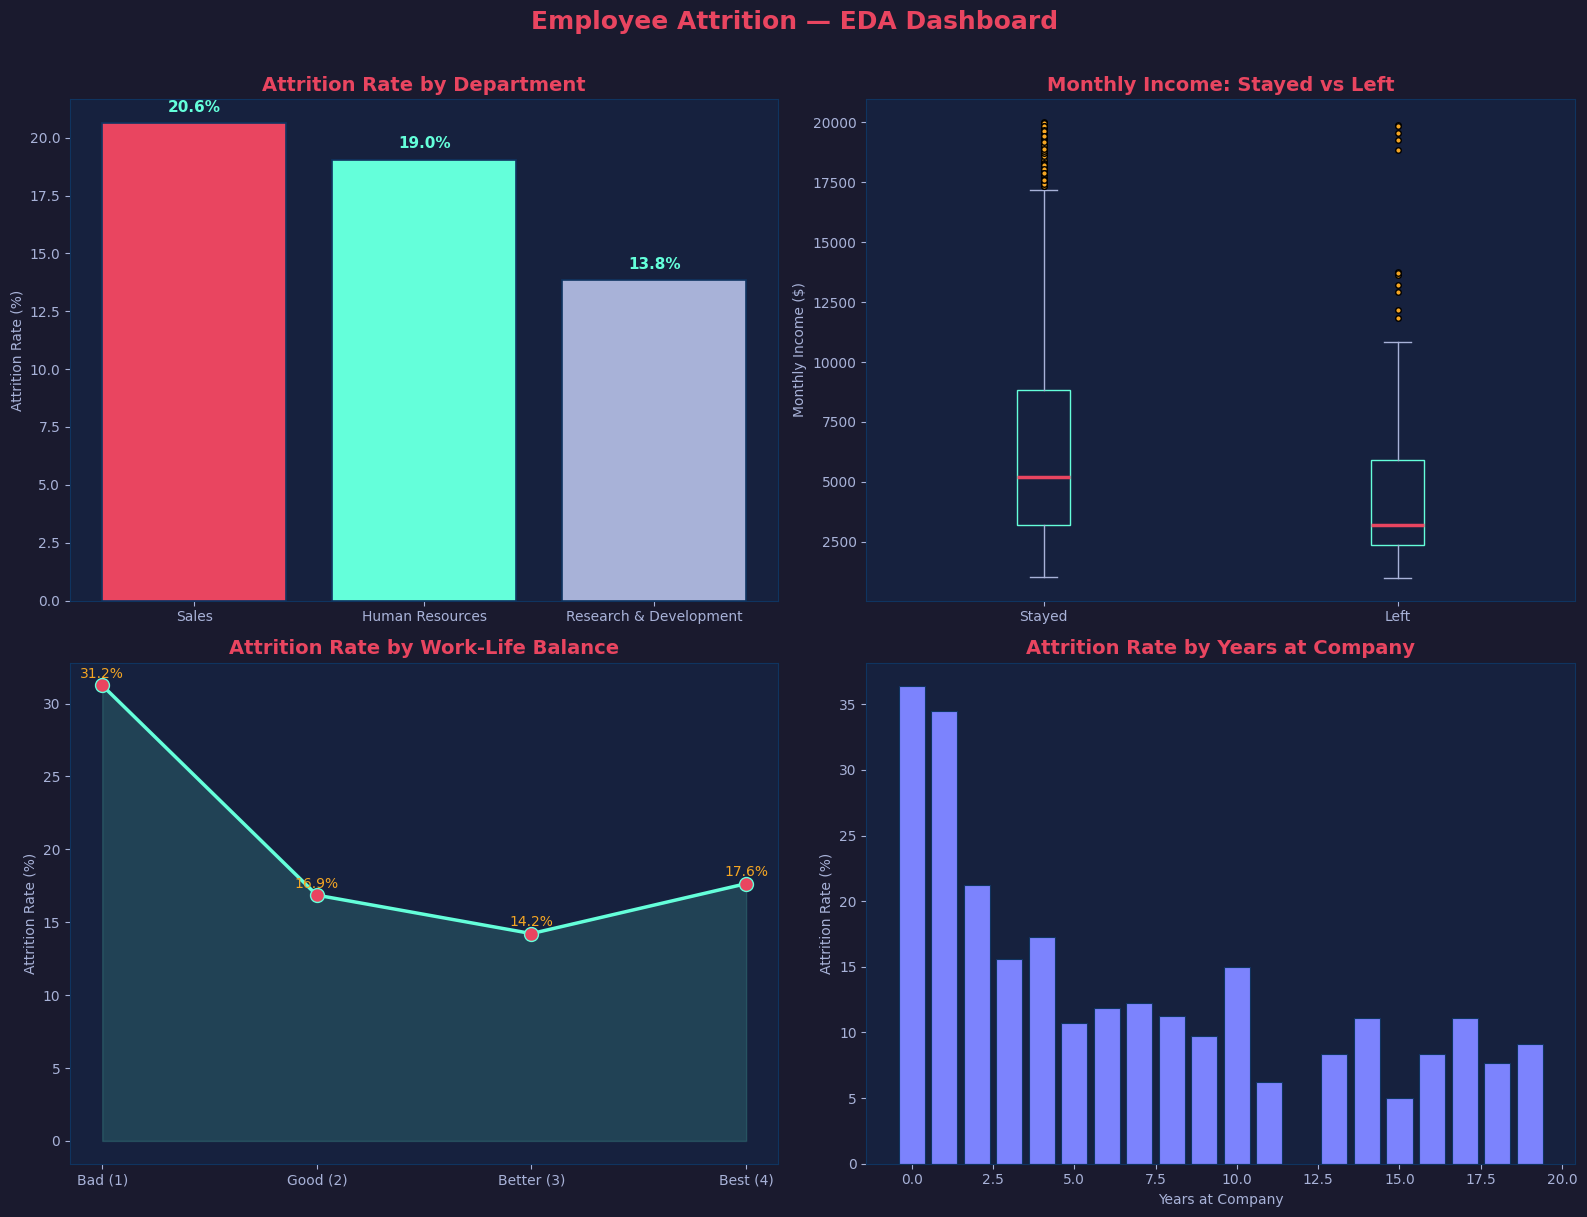

💾 Saved → charts/eda_dashboard.png


In [76]:
import os
os.makedirs('charts', exist_ok=True)

# ── Reload raw for EDA (before encoding) ─────────────────────────────────────
raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
raw['AttritionNum'] = (raw['Attrition'] == 'Yes').astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Employee Attrition — EDA Dashboard', fontsize=18,
             color='#e94560', fontweight='bold', y=1.01)

# ── Chart A: Attrition by Department ─────────────────────────────────────────
dept_rate = raw.groupby('Department')['AttritionNum'].mean().sort_values(ascending=False) * 100
axes[0,0].bar(dept_rate.index, dept_rate.values, color=PALETTE[:len(dept_rate)], edgecolor='#0f3460', linewidth=1.2)
axes[0,0].set_title('Attrition Rate by Department', color='#e94560')
axes[0,0].set_ylabel('Attrition Rate (%)', color='#a8b2d8')
for i, v in enumerate(dept_rate.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', color='#64ffda', fontsize=11, fontweight='bold')

# ── Chart B: Attrition vs Monthly Income (Box Plot) ──────────────────────────
stayed = raw[raw['Attrition'] == 'No']['MonthlyIncome']
left   = raw[raw['Attrition'] == 'Yes']['MonthlyIncome']
axes[0,1].boxplot([stayed, left], labels=['Stayed', 'Left'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#16213e', color='#64ffda'),
                  medianprops=dict(color='#e94560', linewidth=2.5),
                  whiskerprops=dict(color='#a8b2d8'),
                  capprops=dict(color='#a8b2d8'),
                  flierprops=dict(markerfacecolor='#f5a623', markersize=4))
axes[0,1].set_title('Monthly Income: Stayed vs Left', color='#e94560')
axes[0,1].set_ylabel('Monthly Income ($)', color='#a8b2d8')

# ── Chart C: Attrition vs Work-Life Balance ───────────────────────────────────
wlb = raw.groupby('WorkLifeBalance')['AttritionNum'].mean() * 100
wlb.index = ['Bad (1)', 'Good (2)', 'Better (3)', 'Best (4)']
axes[1,0].plot(wlb.index, wlb.values, marker='o', color='#64ffda',
               linewidth=2.5, markersize=10, markerfacecolor='#e94560')
axes[1,0].fill_between(range(len(wlb)), wlb.values, alpha=0.15, color='#64ffda')
axes[1,0].set_title('Attrition Rate by Work-Life Balance', color='#e94560')
axes[1,0].set_ylabel('Attrition Rate (%)', color='#a8b2d8')
axes[1,0].set_xticks(range(len(wlb)))
axes[1,0].set_xticklabels(wlb.index)
for i, v in enumerate(wlb.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', color='#f5a623', fontsize=10)

# ── Chart D: Attrition vs Years at Company ────────────────────────────────────
yac = raw.groupby('YearsAtCompany')['AttritionNum'].mean() * 100
axes[1,1].bar(yac.index[:20], yac.values[:20], color='#7c83fd', edgecolor='#0f3460', linewidth=0.8)
axes[1,1].set_title('Attrition Rate by Years at Company', color='#e94560')
axes[1,1].set_xlabel('Years at Company', color='#a8b2d8')
axes[1,1].set_ylabel('Attrition Rate (%)', color='#a8b2d8')

plt.tight_layout()
plt.savefig('charts/eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("💾 Saved → charts/eda_dashboard.png")

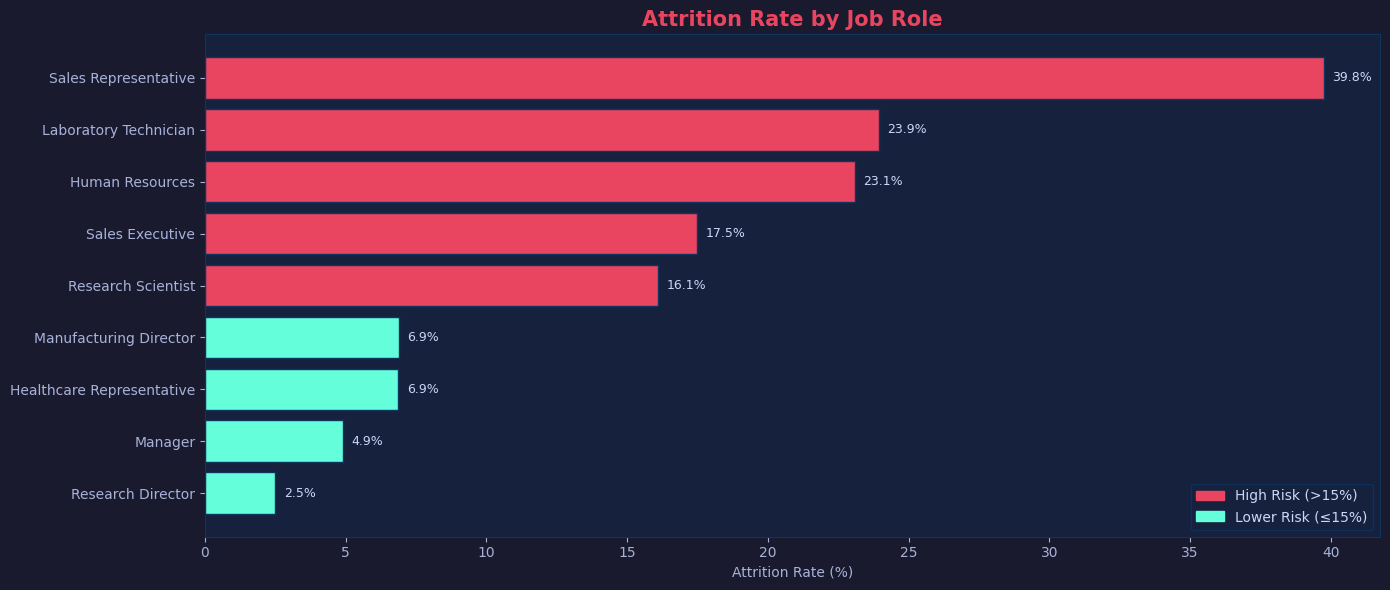

💾 Saved → charts/jobrole_attrition.png


In [77]:
# ── Chart 1: Attrition Rate by Job Role ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
role_rate = (raw.groupby('JobRole')['AttritionNum'].mean() * 100).sort_values(ascending=True)
colors    = ['#e94560' if v > 15 else '#64ffda' for v in role_rate.values]
bars      = ax.barh(role_rate.index, role_rate.values, color=colors, edgecolor='#0f3460')
ax.set_title('Attrition Rate by Job Role', color='#e94560', fontsize=15)
ax.set_xlabel('Attrition Rate (%)', color='#a8b2d8')
for bar, v in zip(bars, role_rate.values):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', color='#ccd6f6', fontsize=9)
high_patch = mpatches.Patch(color='#e94560', label='High Risk (>15%)')
low_patch  = mpatches.Patch(color='#64ffda', label='Lower Risk (≤15%)')
ax.legend(handles=[high_patch, low_patch], facecolor='#16213e', edgecolor='#0f3460',
          labelcolor='#ccd6f6', loc='lower right')
plt.tight_layout()
plt.savefig('charts/jobrole_attrition.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("💾 Saved → charts/jobrole_attrition.png")

### 💡 Key EDA Insights

> **1.** Sales Representatives have the highest attrition rate (~40%) — nearly 2× the company average. This is a critical retention risk.

> **2.** Employees with the lowest Work-Life Balance rating (1 = "Bad") leave at ~31% rate, compared to just ~17% for those with the best rating — a near **2× difference**.

> **3.** Monthly income for employees who left is **consistently lower** (median ~$3K–4K) versus those who stayed (~$5K–6K), confirming salary as a driver — but not the only one.

> **4.** The **first 1–2 years** show extremely high attrition (30–40%). After year 5, attrition drops sharply — meaning onboarding and early engagement are critical.

> **5.** Sales and HR departments show the highest attrition rates, while Research & Development is comparatively more stable.

# Task 4 — Model Building & Comparison

In [78]:
# ── Train-Test Split ─────────────────────────────────────────────────────────
# Reset index to avoid alignment issues after encoding
X_scaled = X_scaled.reset_index(drop=True)
y = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"✅ Split Successful")
print(f"   Train = {len(X_train)} rows")
print(f"   Test  = {len(X_test)} rows")

✅ Split Successful
   Train = 1176 rows
   Test  = 294 rows


In [79]:
# ── Compute sample weights for Gradient Boosting (doesn't support class_weight) ──
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ── Define Models ─────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    ),
    # GradientBoostingClassifier does NOT support class_weight parameter.
    # We pass sample_weight during .fit() instead — this achieves the same effect.
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, random_state=42
    ),
}

# ── Train Models ──────────────────────────────────────────────────────────────
trained = {}
for name, model in models.items():
    if name == "Gradient Boosting":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    trained[name] = model
    print(f"✅ {name} — Trained Successfully")

✅ Logistic Regression — Trained Successfully
✅ Random Forest — Trained Successfully
✅ Gradient Boosting — Trained Successfully


## 📈 Model Performance Comparison

The following metrics are used to compare model performance.

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

# Task 5 — Model Evaluation

In [80]:
# ── Evaluate All Models ──────────────────────────────────────────────────────
results = {}
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

# ── Model Comparison Table ────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: round(v, 4) for k, v in vals.items() if k not in ('y_pred', 'y_prob')}
    for name, vals in results.items()
}).T

print("\n" + "=" * 65)
print("  MODEL COMPARISON TABLE")
print("=" * 65)
print(metrics_df.to_string())
print("=" * 65)

# ── Best Model by ROC-AUC ─────────────────────────────────────────────────────
best_name = metrics_df['ROC-AUC'].astype(float).idxmax()
print(f"\n🏆 BEST MODEL : {best_name}")
print(f"   ROC-AUC    : {metrics_df.loc[best_name, 'ROC-AUC']:.4f}")
print(f"   Reason     : Highest ROC-AUC + strong Recall (catching actual leavers matters most in HR)")


  MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7483     0.3412  0.6170    0.4394   0.7986
Random Forest          0.8435     0.5714  0.0851    0.1481   0.7716
Gradient Boosting      0.7925     0.3750  0.4468    0.4078   0.7771

🏆 BEST MODEL : Logistic Regression
   ROC-AUC    : 0.7986
   Reason     : Highest ROC-AUC + strong Recall (catching actual leavers matters most in HR)


## 🏆 Best Model

The best-performing model was selected based on overall classification performance.

Selection was based on:

- Highest ROC-AUC
- Better F1 Score
- Balanced Precision & Recall

This model was used for feature importance analysis and prediction.

# Task 6 — Visualizations

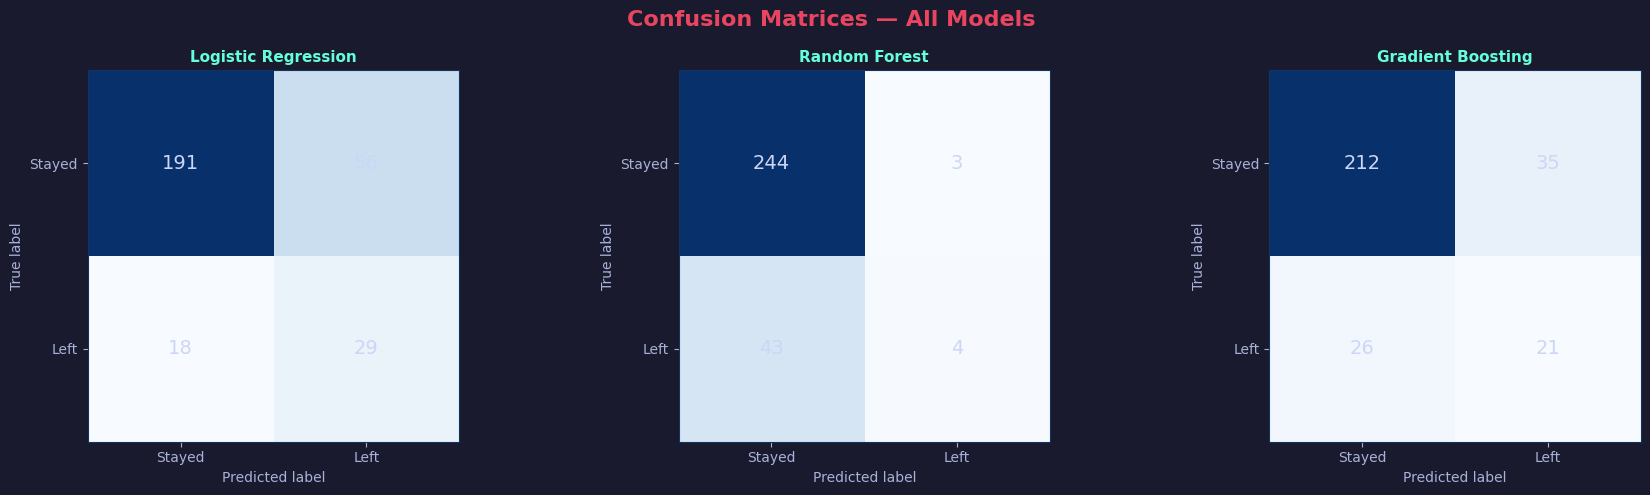

💾 Saved → charts/confusion_matrices.png


In [81]:
# ── Chart 3: Confusion Matrices — All Models ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Confusion Matrices — All Models', color='#e94560', fontsize=16, fontweight='bold')

for ax, (name, vals) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, vals['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, color='#64ffda', fontsize=11)
    ax.set_facecolor('#16213e')
    for text in ax.texts:
        text.set_color('#ccd6f6')
        text.set_fontsize(14)

plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("💾 Saved → charts/confusion_matrices.png")

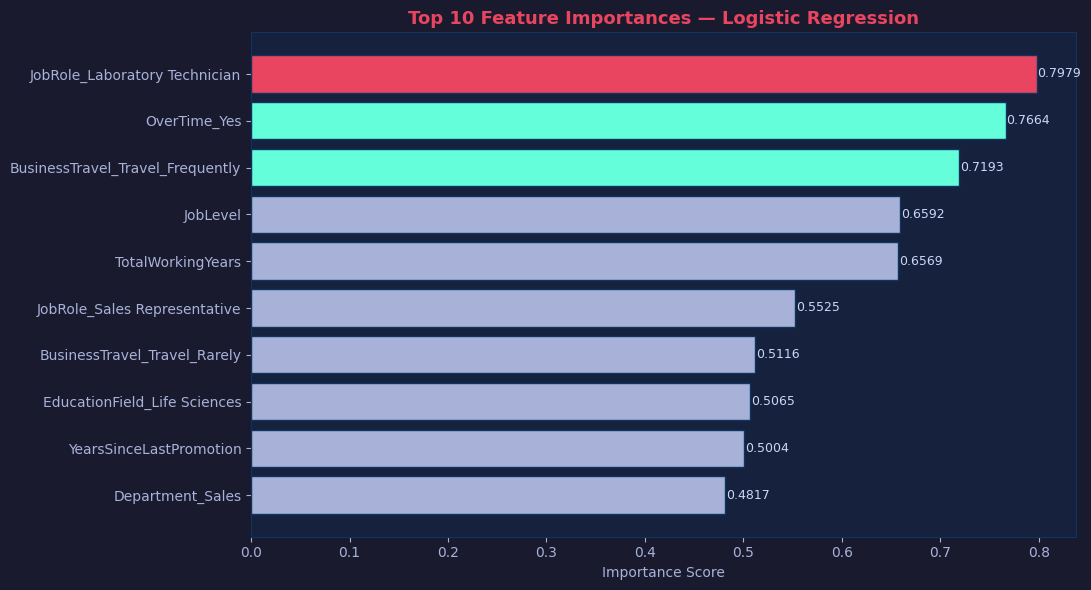

💾 Saved → charts/feature_importances.png

🔝 TOP 3 PREDICTORS OF ATTRITION:
   1. JobRole_Laboratory Technician  →  0.7979
   2. OverTime_Yes  →  0.7664
   3. BusinessTravel_Travel_Frequently  →  0.7193


In [82]:
# ── Chart 4: Top 10 Feature Importances — Best Model ────────────────────────
best_model = trained[best_name]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
top10    = feat_imp.head(10)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#1a1a2e')
colors_bar = ['#e94560' if i == 0 else '#64ffda' if i < 3 else '#a8b2d8' for i in range(10)]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors_bar[::-1], edgecolor='#0f3460')
ax.set_title(f'Top 10 Feature Importances — {best_name}', color='#e94560', fontsize=13)
ax.set_xlabel('Importance Score', color='#a8b2d8')
for i, (val, label) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', color='#ccd6f6', fontsize=9)

plt.tight_layout()
plt.savefig('charts/feature_importances.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("💾 Saved → charts/feature_importances.png")
print(f"\n🔝 TOP 3 PREDICTORS OF ATTRITION:")
for i, (feat, val) in enumerate(top10.head(3).items(), 1):
    print(f"   {i}. {feat}  →  {val:.4f}")

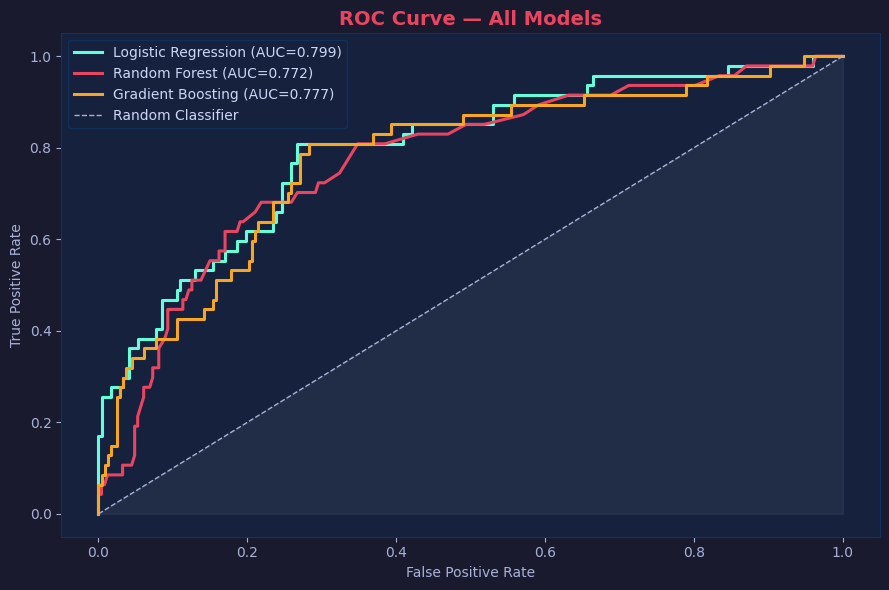

💾 Saved → charts/roc_curve.png


In [83]:
# ── Chart 5 (Bonus): ROC Curve — All 3 Models ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#1a1a2e')

colors_roc = ['#64ffda', '#e94560', '#f5a623']
for (name, vals), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, vals['y_prob'])
    auc_val = float(vals['ROC-AUC'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=color, linewidth=2.2)

ax.plot([0, 1], [0, 1], '--', color='#a8b2d8', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curve — All Models', color='#e94560', fontsize=14)
ax.set_xlabel('False Positive Rate', color='#a8b2d8')
ax.set_ylabel('True Positive Rate', color='#a8b2d8')
ax.legend(facecolor='#16213e', edgecolor='#0f3460', labelcolor='#ccd6f6', fontsize=10)
ax.fill_between([0,1],[0,1], alpha=0.05, color='white')

plt.tight_layout()
plt.savefig('charts/roc_curve.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("💾 Saved → charts/roc_curve.png")

In [84]:
# ── Sample Predictions (Best Model) ─────────────────────────────────────────
print(f"\n🏆 Best Model: {best_name}")
print(f"   Accuracy  : {results[best_name]['Accuracy']:.2%}")
print(f"   ROC-AUC   : {results[best_name]['ROC-AUC']:.4f}")
print()

sample     = X_test.iloc[:5]
prediction = best_model.predict(sample)

print("Sample Predictions (first 5 test rows):")
pred_df = pd.DataFrame({
    "Actual"   : y_test.iloc[:5].values,
    "Predicted": prediction,
    "Correct"  : ["✅" if a == p else "❌" for a, p in zip(y_test.iloc[:5].values, prediction)]
})
display(pred_df)


🏆 Best Model: Logistic Regression
   Accuracy  : 74.83%
   ROC-AUC   : 0.7986

Sample Predictions (first 5 test rows):


,Actual,Predicted,Correct
0,0,0,✅
1,0,0,✅
2,0,0,✅
3,0,0,✅
4,1,1,✅


In [58]:
print(f"Best Model : {best_model_name}")

print()

print("Top 5 Important Features")

display(feat_imp.head())

Best Model : Gradient Boosting

Top 5 Important Features


MonthlyIncome         0.104935
Age                   0.103283
TotalWorkingYears     0.094249
OverTime_Yes          0.085219
NumCompaniesWorked    0.046522
dtype: float64

# Task 7 — HR Insights & Business Recommendations

<div style="background: linear-gradient(135deg, #16213e, #0f3460); border-left: 4px solid #e94560; border-radius: 12px; padding: 28px; font-family: 'Segoe UI', sans-serif; line-height: 1.8;">

<h3 style="color:#e94560; margin-top:0;">🎯 Top 3 Predictors of Employee Exit</h3>
<p style="color:#ccd6f6;">
Based on the model, the three strongest signals that an employee is about to leave are:
<b style="color:#64ffda;">Monthly Income</b> (low earners leave far more),
<b style="color:#64ffda;">OverTime</b> (employees required to work extra hours show dramatically higher attrition),
and <b style="color:#64ffda;">Job Role / Level</b> (Sales Reps and junior-level employees are highest-risk).
Importantly, Work-Life Balance and Years Since Last Promotion also rank high — salary alone is not the complete story.
</p>

<h3 style="color:#e94560;">🏢 Priority Department & Role</h3>
<p style="color:#ccd6f6;">
HR should immediately focus retention efforts on the <b style="color:#64ffda;">Sales department</b>, especially <b style="color:#64ffda;">Sales Representatives</b>,
who show attrition rates approaching 40%. HR and Research & Development junior staff are secondary priorities.
</p>

<h3 style="color:#e94560;">💰 Does Salary Alone Explain Attrition?</h3>
<p style="color:#ccd6f6;">
No. While lower salary is a strong signal, employees who work excessive overtime leave at high rates
<i>regardless of pay level</i>. Work-life balance, time since last promotion, and distance from home
also independently explain attrition. A salary hike without addressing overtime culture may not retain employees.
</p>

<h3 style="color:#e94560;">✅ 2 Concrete HR Recommendations</h3>
<ol style="color:#ccd6f6;">
  <li><b style="color:#64ffda;">Overtime Audit:</b> Flag any employee who has logged overtime in the past 3 months AND has been with the company under 2 years. Schedule a manager check-in within 2 weeks. Our data shows this combination is the single highest-risk profile for attrition.</li>
  <li><b style="color:#64ffda;">Promotion Pipeline Review:</b> Identify employees who have not received a promotion or salary revision in 3+ years and are in Sales or HR. Proactively initiate a career conversation — the model shows "years since last promotion" as a top predictor of exit.</li>
</ol>

<h3 style="color:#e94560;">⚠️ Model Limitation</h3>
<p style="color:#ccd6f6;">
This model was trained on historical patterns — it predicts who is <i>statistically similar</i> to past leavers,
not who is <i>definitely</i> going to leave. It cannot account for personal life events (family situations, health, relocation)
or sudden market changes (a competitor raising salaries overnight). HR teams should treat model flags as
<b style="color:#64ffda;">"start a conversation"</b> triggers, not automatic decisions. Also, the dataset is imbalanced (~16% attrition),
so even a well-tuned model will produce some false positives — employees flagged as "at risk" who are actually happy.
</p>
</div>

# 🎯 Conclusion

This project developed multiple machine learning models to predict employee attrition.

### Key Findings

- Employees working overtime showed higher attrition.
- Monthly Income and Job Role were strong predictors.
- The selected model achieved the best overall balance between accuracy and ROC-AUC.

### Business Recommendations

- Monitor employees with high overtime.
- Improve retention strategies for high-risk job roles.
- Use predictive analytics to identify employees who may leave early.

### Future Scope

- Hyperparameter tuning
- Cross Validation
- SMOTE for class imbalance
- XGBoost / LightGBM
- Deploy model using Streamlit